# Distance to Substation Suitability Index (SI) Calculation

This notebook calculates the Suitability Index based on distance to existing substations for renewable energy siting in Thailand.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mplPath
from matplotlib import pyplot
import geopandas as gpd
import pandas as pd
import cartopy.io.shapereader as shpreader
import geodatasets
import xarray as xr
import numpy as np
from geopandas import GeoSeries
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point , Polygon, MultiPolygon
from shapely.geometry.multipolygon import MultiPolygon
import shapely.wkt
import shapely.geometry
import shapely
from shapely.ops import nearest_points
from pathlib import Path
import rasterio
import rioxarray

## 1. Import Required Libraries

Import all necessary libraries for data processing, geospatial operations, and visualization.

In [2]:
subs_wlatlon = pd.read_csv("Data\\SUB_EGAT.csv")
subs_wlatlon.reset_index(inplace=True,drop=True)
subs_wlatlon = gpd.GeoDataFrame(subs_wlatlon, geometry =gpd.points_from_xy(subs_wlatlon['LONG,N,19,11'],subs_wlatlon['LAT,N,19,11']))
subs_wlatlon = subs_wlatlon.loc[subs_wlatlon['STATUS,C,50'] == 'EXISTING']
subs_wlatlon.reset_index(inplace=True,drop=True)
subs_wlatlon.crs = 'EPSG:4326'
print(subs_wlatlon)

    STATIONID,C,4     NAME_E,C,100 SUBNAME_T,C,100  \
0              AN    AMNAT CHAROEN   สฟ.อำนาจเจริญ   
1              AP          AO PHAI      สฟ.อ่าวไผ่   
2             AT1      ANG THONG 1    สฟ.อ่างทอง 1   
3             AT2      ANG THONG 2    สฟ.อ่างทอง 2   
4             AY1      AYUTTHAYA 1     สฟ.อยุธยา 1   
..            ...              ...             ...   
246            WN         WANG NOI      สฟ.วังน้อย   
247           WNK  WATTHANA NAKHON     สฟ.วัฒนานคร   
248           YL1           YALA 1       สฟ.ยะลา 1   
249           YL2           YALA 2       สฟ.ยะลา 2   
250            YT         YASOTHON        สฟ.ยโสธร   

                                        LOCATION,C,254  LAT,N,19,11  \
0    165 หมู่ 2 ถ.ชยางกูร ต.ไก่ดำ อ.เมือง จ.อำนาจเจ...    15.808659   
1     285 หมู่ 6 ต.ทุ่งสุขลา อ.ศรีราชา จ.ชลบุรี  20230    13.126233   
2       68  หมู่ 11 ต.บ้านอิฐ อ.เมือง จ.อ่างทอง  14000    14.583561   
3            ต.ม่วงเตี้ย อ.วิเศษชัยชาญ จ.อ่างทอง 14110    14.612462

## 2. Load Substation Data and Compute Distance and Suitability Index

Load the existing substations data, Thailand boundary, land cover data, project coordinates, compute distances using KDTree, apply mask, normalize to SI values, and create xarray dataset.

In [3]:
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp').to_crs(epsg=4326)
thailand_poly = thailandmap.geometry.union_all()

min_lon, min_lat, max_lon, max_lat = thailand_poly.bounds
print('thailand bounds', min_lon, min_lat, max_lon, max_lat)

xr_landuse = xr.open_dataset('Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc')
print('src lat first/last', xr_landuse.lat.values[0], xr_landuse.lat.values[-1])
print('src lon first/last', xr_landuse.lon.values[0], xr_landuse.lon.values[-1])

# Use the correct order for lat slice depending on axis order
xr_sel = xr_landuse.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
print('sel lat len', xr_sel.lat.size, 'first/last', xr_sel.lat.values[0] if xr_sel.lat.size>0 else None, xr_sel.lat.values[-1] if xr_sel.lat.size>0 else None)

xr_sel_rev = xr_landuse.sel(lat=slice(max_lat, min_lat), lon=slice(min_lon, max_lon))
print('sel_rev lat len', xr_sel_rev.lat.size, 'first/last', xr_sel_rev.lat.values[0] if xr_sel_rev.lat.size>0 else None, xr_sel_rev.lat.values[-1] if xr_sel_rev.lat.size>0 else None)

if xr_sel.lat.size > 0:
    xr_landuse = xr_sel
elif xr_sel_rev.lat.size > 0:
    xr_landuse = xr_sel_rev
else:
    raise RuntimeError('No lat selection could be built; verify bounds and dataset orientation')

xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')

lc = xr_landuse['lccs_class']
lon_vals = lc.lon.values
lat_vals = lc.lat.values
nlat = lat_vals.size
nlon = lon_vals.size

# mask Thailand in lon/lat using rasterization (fast, avoids per-point Python loop)
from rasterio import features
from affine import Affine

transform = Affine.translation(lon_vals[0], lat_vals[0]) * Affine.scale(lon_vals[1] - lon_vals[0], lat_vals[1] - lat_vals[0])
mask_th = features.geometry_mask([thailand_poly.__geo_interface__], out_shape=(nlat, nlon), transform=transform, invert=True)
mask_th = np.asarray(mask_th, dtype=bool)
print('mask_th sum', mask_th.sum(), 'shape', mask_th.shape)

if mask_th.sum() == 0:
    raise RuntimeError('Empty masking region: Thailand polygon not covering the grid properly')

# prepare working points only for Thailand area
valid_idx = np.where(mask_th.ravel())[0]
lat_idx = valid_idx // nlon
lon_idx = valid_idx % nlon
pts_lon = lon_vals[lon_idx]
pts_lat = lat_vals[lat_idx]

proj = Transformer.from_crs('EPSG:4326', 'EPSG:32647', always_xy=True)
pts_x, pts_y = proj.transform(pts_lon, pts_lat)
pts_xy = np.column_stack([pts_x, pts_y])

subs_x, subs_y = proj.transform(subs_wlatlon['LONG,N,19,11'].values, subs_wlatlon['LAT,N,19,11'].values)
subs_xy = np.column_stack([subs_x, subs_y])

from scipy.spatial import cKDTree
subs_tree = cKDTree(subs_xy)

dists, _ = subs_tree.query(pts_xy, k=1)

dist_m = np.zeros((nlat, nlon), dtype=np.float32)
dist_m.flat[valid_idx] = dists.astype(np.float32)

default_outside = 0.0
outside_mask = ~mask_th

min_dist = float(np.min(dists))
max_dist = float(np.max(dists))

# Normalize to SI values directly on mask area
si_temp = np.zeros_like(dist_m, dtype=np.float32)
si_temp.flat[valid_idx] = 3 * (dists - min_dist) / (max_dist - min_dist)
si_temp = np.clip(si_temp, 0, None)
maxscore = float(np.nanmax(si_temp))
si_value = np.zeros_like(si_temp, dtype=np.float32)
si_value.flat[valid_idx] = maxscore - si_temp.flat[valid_idx]

xr_distancetosubs = xr.Dataset(
    {
        'distance': (('lat', 'lon'), dist_m),
        'SI_DtoSubs': (('lat', 'lon'), si_value),
    },
    coords={'lat': lat_vals, 'lon': lon_vals},
)

print(xr_distancetosubs)


thailand bounds 97.34335847100004 5.613037873000053 105.63696451800007 20.46507381500004
src lat first/last 89.99861111111113 -89.99861111111112
src lon first/last -179.9986111111111 179.99861111111113
sel lat len 0 first/last None None
sel_rev lat len 5346 first/last 20.462500000000006 5.615277777777777
mask_th sum 5625151 shape (5346, 2985)
<xarray.Dataset> Size: 128MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance    (lat, lon) float32 64MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_DtoSubs  (lat, lon) float32 64MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


## 3. Save Results

Save the computed dataset to a NetCDF file.

In [4]:
# Save the results and inspect
xr_distancetosubs.to_netcdf(path='Output\\xr_SI_Distancetosubstation.nc')
print(xr_distancetosubs)


<xarray.Dataset> Size: 128MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance    (lat, lon) float32 64MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_DtoSubs  (lat, lon) float32 64MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


## 4. Visualize Results

Plot the Suitability Index maps.

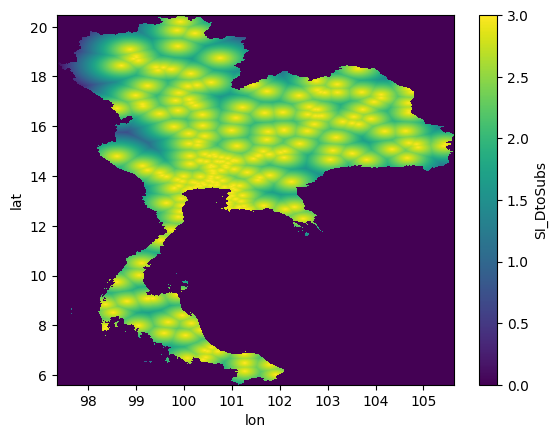

In [5]:
xr_distancetosubs['SI_DtoSubs'].plot()

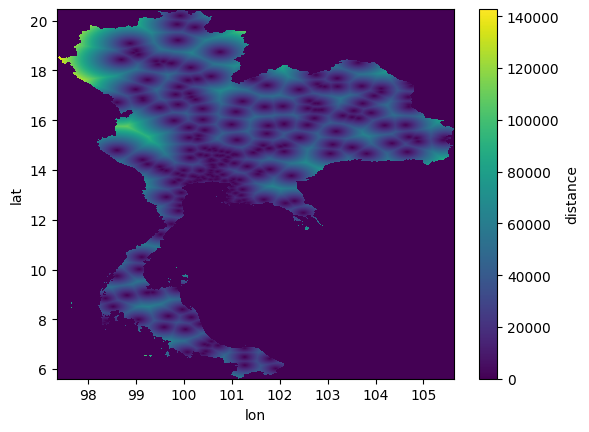

In [6]:
xr_distancetosubs['distance'].plot()